### Debug

In [201]:
splits = pd.read_csv('/opt/app/user/splits.csv')

In [202]:
splits.columns

Index(['Patient_id', 'wsi_path', 'Diagnose', 'selected', 'slide_id',
       'mask_path', 'fold'],
      dtype='object')

In [207]:
splits.groupby(['fold','Diagnose']).size().head(15)

fold  Diagnose     
1     Diffuse          14
      Focal             2
      Not Anaplasia    24
2     Diffuse          31
      Not Anaplasia    16
3     Diffuse          22
      Not Anaplasia    16
4     Diffuse          13
      Not Anaplasia    16
5     Diffuse           7
      Focal             1
      Not Anaplasia    16
dtype: int64

In [74]:
all_yes_splits = splits[splits['selected']=='yes']

In [77]:
all_yes_splits.to_csv('/opt/app/user/all_yes.csv',index=False)

In [134]:
feature_matrix = np.vstack(results_df["feature"].values)

In [135]:
features

0      [0.0, 0.44056773, 0.100598305, 0.0, 2.0321643,...
1      [0.0, 0.0, 0.0, 0.0, 2.993336, 1.9318857, 5.12...
2      [0.0, 0.44698948, 0.0, 0.0, 3.0542095, 2.05716...
3      [0.04492466, 1.9229231, 0.68826735, 0.0, 2.248...
4      [0.0, 0.0, 0.0, 0.0, 1.8951005, 0.76222515, 2....
                             ...                        
160    [0.0, 1.7081562, 2.6081872, 0.31952208, 0.0, 1...
161    [0.3910042, 0.38250786, 0.42455456, 1.2461689,...
162    [0.10491803, 0.1683542, 0.30274847, 1.2154233,...
163    [0.0, 2.2173328, 2.6715455, 0.038741887, 0.0, ...
164    [0.0, 0.3174966, 0.041943826, 2.441502, 0.0, 0...
Name: feature, Length: 165, dtype: object

In [137]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2D = tsne.fit_transform(feature_matrix)

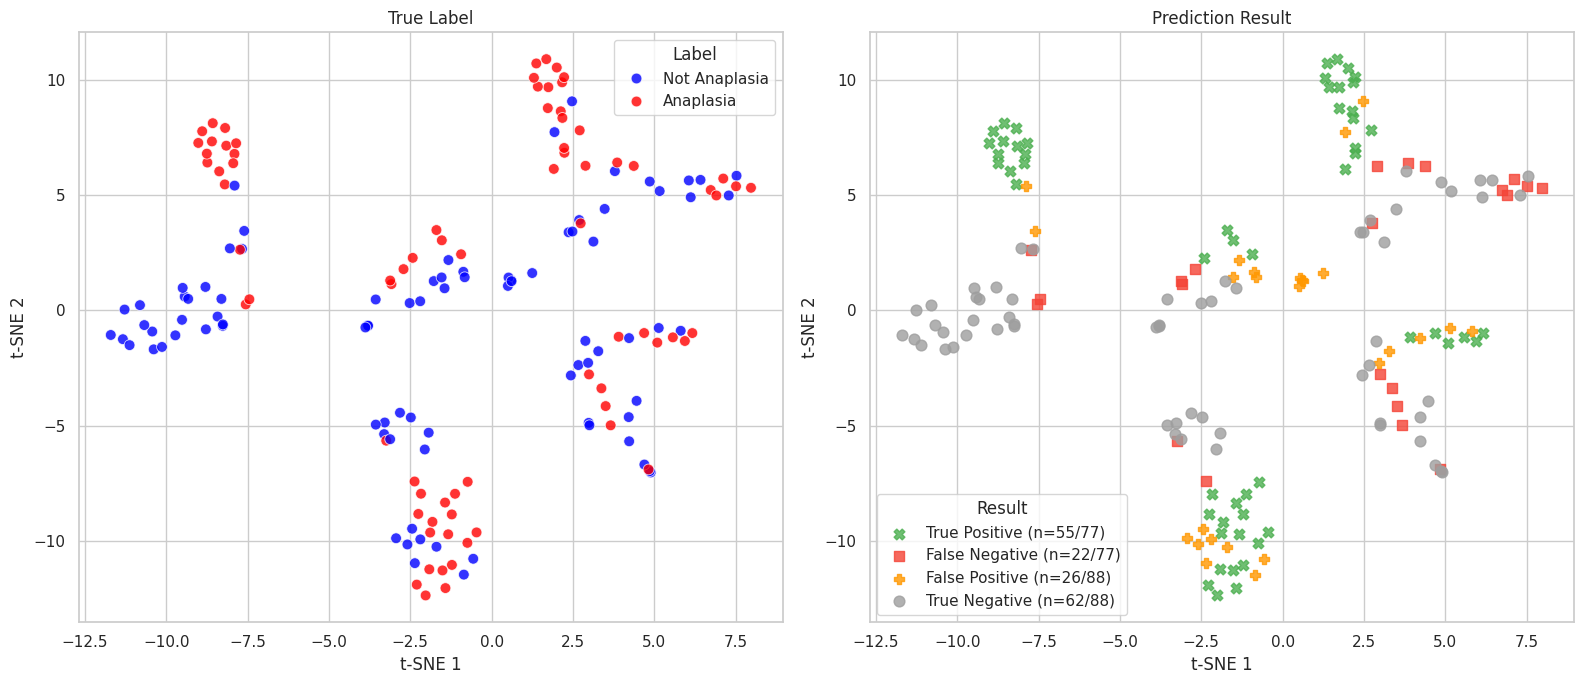

In [138]:
plot_type = ["label", "prediction_result"]
save_path = f"/opt/app/user/Experiments/{model_name2}/label_prediction"
plot_features(X_2D, results_df, plot_type=plot_type, save_path=save_path)

In [66]:
wrong_preds_df = all_patients[all_patients['true_label'] != all_patients['pred_label']]
wrong_preds_df.to_csv('Experiments/multi_layer/all_slides/wrong_predictions.csv',index=False)


In [67]:
results_df = all_patients.copy()
features_all, labels_all = dataset.load()
X_2D = run_tSNE(features_all)

Running t-SNE...


In [68]:
error_patients = wrong_preds_df["patient_id"].unique()
df_error_subset = results_df[results_df["patient_id"].isin(error_patients)].copy()
df_error_subset["tsne_x"] = X_2D[df_error_subset.index, 0]
df_error_subset["tsne_y"] = X_2D[df_error_subset.index, 1]


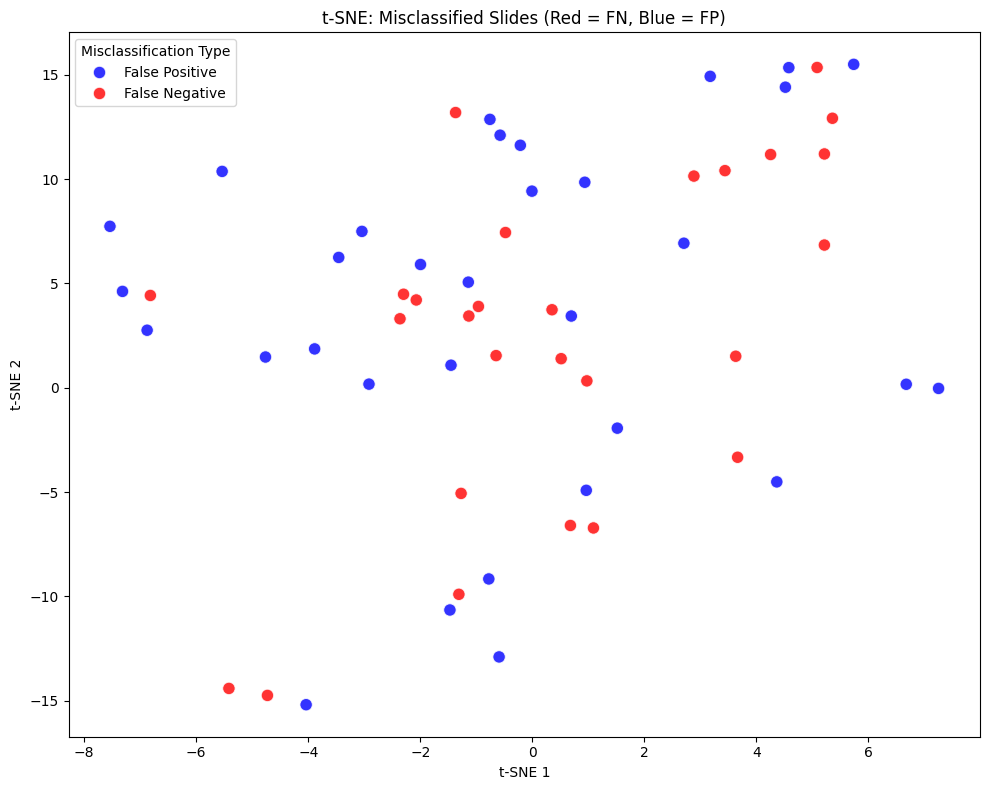

In [71]:
# Define color by prediction type
def get_error_type(row):
    if row["true_label"] == 1 and row["pred_label"] == 0:
        return "False Negative"
    elif row["true_label"] == 0 and row["pred_label"] == 1:
        return "False Positive"
    else:
        return "Other"

df_error_subset["error_type"] = df_error_subset.apply(get_error_type, axis=1)

# Filter only FP and FN
df_errors_only = df_error_subset[df_error_subset["error_type"].isin(["False Negative", "False Positive"])]

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne_x",
    y="tsne_y",
    hue="error_type",
    data=df_errors_only,
    palette={"False Negative": "red", "False Positive": "blue"},
    s=80,
    alpha=0.8
)

plt.title("t-SNE: Misclassified Slides (Red = FN, Blue = FP)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Misclassification Type")
plt.tight_layout()
plt.show()


In [11]:
all_patients.describe()

,Patient_id,wsi_path,Diagnose,selected,slide_id,mask_path
count,178,178,178,178,178,178
unique,22,178,3,2,178,178
top,WT_S01_P000105,/data/pa_cpgarchive/archives/kidney/Wilms_Tumo...,Not Anaplasia,yes,WT_S01_P000108_B201_V01_C0001_T02_L01_A15_E21,/data/temporary/pierpaolo/tb/WT_S01_P000108_B2...
freq,19,1,88,165,1,1


In [12]:
all_patients.to_csv('/opt/app/user/wilms_complete.csv',index=False)

In [13]:
filtered_df = all_patients[all_patients["selected"] == 'yes']
filtered_df.to_csv('/opt/app/user/wilms_only_yes.csv',index=False)


In [18]:
label_csv = "/opt/app/user/wilms_complete.csv"
feature_dir = "/opt/app/user/total_features/features/"
dataset = FeatureDataset(
    feature_dir=feature_dir,
    label_csv=label_csv,
    binary=True
)

✅ Loaded 178 slides from /opt/app/user/total_features/features/


In [20]:
def generate_patient_folds_binary(wilmstumor_csv, output_csv, n_splits=5, random_state=42):
    """
    Generate patient-level k-fold split for binary classification:
    Not Anaplasia (0) vs. [Focal + Diffuse] (1).

    Parameters
    ----------
    wilmstumor_csv : str
        Path to original CSV with 'Patient_id', 'Diagnose', 'slide_id'.
    output_csv : str
        Path to save the updated CSV with 'fold' column.
    n_splits : int
        Number of CV folds.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Updated dataframe with 'fold' column added.
    """

    # Load data
    df = pd.read_csv(wilmstumor_csv)

    # Create patient-level table
    patient_df = df.groupby("Patient_id").first().reset_index()[["Patient_id", "Diagnose"]]

    # Map to binary classes
    binary_map = {"Not Anaplasia": 0, "Focal": 1, "Diffuse": 1}
    patient_df["label"] = patient_df["Diagnose"].map(binary_map)

    # Check for missing or unknown labels
    if patient_df["label"].isnull().any():
        unknowns = patient_df[patient_df["label"].isnull()]["Diagnose"].unique()
        raise ValueError(f"❌ Unknown label(s) in data: {unknowns}")

    # Stratified fold split
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    patient_df["fold"] = -1
    for fold, (_, val_idx) in enumerate(skf.split(patient_df["Patient_id"], patient_df["label"])):
        patient_df.loc[val_idx, "fold"] = fold + 1

    # Merge back into full slide-level DataFrame
    df = df.merge(patient_df[["Patient_id", "fold"]], on="Patient_id", how="left")

    # Save
    df.to_csv(output_csv, index=False)
    print(f"✅ Binary-stratified patient folds saved to: {output_csv}")

    return df


In [22]:
df_splits = generate_patient_folds_binary(label_csv, output_csv='/opt/app/user/splits.csv')

✅ Binary-stratified patient folds saved to: /opt/app/user/splits.csv


In [19]:
# Get patient ID per sample
patient_ids = [os.path.basename(p[0])[:14] for p in dataset.samples]

# Get patient-stratified dataloaders
folds = get_patient_stratified_dataloaders(dataset, batch_size=32)

# Collect which patients appear in which fold
fold_patient_map = defaultdict(set)

for fold_idx, (_, val_loader) in enumerate(folds):
    fold_num = fold_idx + 1

    # Get the original indices used in this fold
    _, _, val_index_batches = zip(*[batch for batch in val_loader])
    val_indices = torch.cat(val_index_batches).numpy()

    for idx in val_indices:
        pid = patient_ids[int(idx)]
        fold_patient_map[pid].add(fold_num)

# Check for patients in multiple folds
leaking_patients = {pid: folds for pid, folds in fold_patient_map.items() if len(folds) > 1}

if leaking_patients:
    print("🚨 Patient leakage detected across folds!")
    for pid, folds in leaking_patients.items():
        print(f"Patient {pid} appears in folds: {sorted(folds)}")
else:
    print("✅ No patient leakage detected. Splitting is clean.")


🚨 Patient leakage detected across folds!
Patient WT_S01_P000011 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000077 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000107 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000040 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000016 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000050 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000084 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000041 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000105 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000087 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000057 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000032 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000074 appears in folds: [1, 2, 3, 4, 5]
Patient WT_S01_P000038 appears in folds: [1, 2, 4, 5]
Patient WT_S01_P000012 appears in folds: [1, 2, 4, 5]
Patient WT_S01_P000088 appears in folds: [1, 2, 5]


In [23]:
def check_patient_leakage(csv_path):
    """
    Verifies that each patient appears in only one fold (no leakage).
    
    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing at least ['Patient_id', 'fold'].
    """
    df = pd.read_csv(csv_path)
    
    # Check for patients assigned to multiple folds
    fold_map = df.groupby("Patient_id")["fold"].nunique()
    leaking_patients = fold_map[fold_map > 1]
    
    if leaking_patients.empty:
        print("✅ No patient leakage detected across folds.")
    else:
        print("🚨 Patient leakage found! The following patients appear in multiple folds:")
        print(leaking_patients)

# Example usage:
check_patient_leakage("/opt/app/user/splits.csv")


✅ No patient leakage detected across folds.


# Anaplasia Classification Notebook

## Core Features

### Imports and base functions

In [28]:
# import tqdm
from tqdm import tqdm
import seaborn as sns
import os
import pandas as pd
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from collections import defaultdict
import numpy as np
import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, auc
from sklearn.manifold import TSNE

In [14]:
def create_output_dir(model_name):
    out_dir = os.path.join("/opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/", model_name)
    os.makedirs(out_dir, exist_ok=True)
    return out_dir

### Classifiers, MLP and Linear Layer

In [17]:
class CaseLevelTaskAdaptor(ABC):
    """
    Abstract base class for case-level tasks such as classification or regression.
    This class provides a blueprint for implementing adaptors that operate on a case level,
    where each case is represented by its features and corresponding labels.

    Attributes:
        shot_features (np.ndarray): Feature matrix for the few-shots.
        shot_labels (np.ndarray): Labels corresponding to the few-shots.
        test_features (np.ndarray): Feature matrix for the test set.
        shot_extra_labels (np.ndarray, optional): Additional labels for the few-shots, if applicable. Defaults to None.
    """

    def __init__(
        self,
        shot_features: np.ndarray,
        shot_labels: np.ndarray,
        test_features: np.ndarray,
        shot_extra_labels: np.ndarray = None,
    ):
        """
        Initializes the CaseLevelTaskAdaptor with few-shot and test data.

        Args:
            shot_features (np.ndarray): Feature matrix for the few-shots.
            shot_labels (np.ndarray): Labels corresponding to the few-shots.
            test_features (np.ndarray): Feature matrix for the test set.
            shot_extra_labels (np.ndarray, optional): Additional labels for the few-shots, if applicable.
        """
        self.shot_features = shot_features
        self.shot_labels = shot_labels
        self.test_features = test_features
        self.shot_extra_labels = shot_extra_labels

    @abstractmethod
    def fit(self):
        """
        Abstract method to fit the model using the few-shot data.
        The implementation should use `shot_features` and `shot_labels` to fit the model.
        """
        pass

    @abstractmethod
    def predict(self) -> np.ndarray:
        """
        Abstract method to make predictions using the test data.
        Returns:
            np.ndarray: Predictions for the test set based on `test_features`.
        """
        pass

In [18]:
def preprocess_features(
    shot_features: np.ndarray,
    test_features: np.ndarray,
    center: bool = True,
    normalize_features: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Preprocess feature vectors by centering and normalizing, optionally converting to NumPy.

    Args:
        shot_features (np.ndarray): Few-shot feature matrix of shape (n_shots, n_features).
        test_features (np.ndarray): Test feature matrix of shape (n_test_samples, n_features).
        center: Whether to subtract mean of few-shot features
        normalize_features: Whether to apply L2 normalization

    Returns:
        Preprocessed (shot_features, test_features) as torch.Tensor or np.ndarray
    """
    if center:
        mean_feature = shot_features.mean(dim=0, keepdims=True)
        shot_features = shot_features - mean_feature
        test_features = test_features - mean_feature

    if normalize_features:
        shot_features = shot_features / np.linalg.norm(
            shot_features, axis=-1, keepdims=True
        )
        test_features = test_features / np.linalg.norm(
            test_features, axis=-1, keepdims=True
        )

    return shot_features, test_features


class KNN(CaseLevelTaskAdaptor):
    """
    A class to perform K-Nearest Neighbors (KNN) probing for classification tasks.
    Attributes:
        shot_features (np.ndarray): Few-shot feature matrix of shape (n_shots, n_features).
        shot_labels (np.ndarray): Few-shot labels.
        test_features (np.ndarray): Test feature matrix of shape (n_test_samples, n_features).
        k (int): Number of neighbors to consider for KNN.
        num_workers (int): Number of parallel jobs for sklearn models. Default is 8.
        center_features (bool): Whether to subtract the mean from features. Default is False.
        normalize_features (bool): Whether to L2 normalize features. Default is False.
    Methods:
        fit():
            Fits the KNN model using the provided few-shot features and labels.
        predict() -> np.ndarray:
            Predicts the labels or values for the provided test features.
    """

    def __init__(
        self,
        shot_features,
        shot_labels,
        test_features,
        k,
        num_workers=8,
        center_features=False,
        normalize_features=False,
        return_probabilities=False,
    ):
        super().__init__(shot_features, shot_labels, test_features)
        self.k = k
        self.num_workers = num_workers
        self.center_features = center_features
        self.normalize_features = normalize_features
        self.return_probabilities = return_probabilities
        self.model = None

    def fit(self):
        processed_shot_features, _ = preprocess_features(
            self.shot_features,
            self.test_features,
            center=self.center_features,
            normalize_features=self.normalize_features,
        )

        self.model = KNeighborsClassifier(n_neighbors=self.k, n_jobs=self.num_workers)
        self.model.fit(processed_shot_features, self.shot_labels)

    def predict(self) -> np.ndarray:
        _, processed_test_features = preprocess_features(
            self.shot_features,
            self.test_features,
            center=self.center_features,
            normalize_features=self.normalize_features,
        )

        if self.model is None:
            raise ValueError(
                "Model has not been fitted yet. Call `fit` before `predict`."
            )

        if self.return_probabilities:
            return self.model.predict_proba(processed_test_features)
        return self.model.predict(processed_test_features)


class WeightedKNN(CaseLevelTaskAdaptor):
    """
    WeightedKNN is a k-Nearest Neighbors (k-NN) based adaptor that supports weighted similarity
    for classification tasks. It allows customization of
    distance metrics.
    Attributes:
        shot_features (np.ndarray): Few-shot feature matrix of shape (n_shots, n_features).
        shot_labels (np.ndarray): Few-shot labels.
        test_features (np.ndarray): Test feature matrix of shape (n_test_samples, n_features).
        k (int): Number of nearest neighbors to consider.
        metric (str or callable): Similarity metric to use. Options are "cosine", "euclidean", or a callable function.
        center_features (bool): Whether to center the features during preprocessing.
        normalize_features (bool): Whether to normalize the features during preprocessing.
        return_probabilities (bool): Whether to return class probabilities instead of predictions.
    Methods:
        fit():
            Preprocesses the features and sets up the similarity function and class-related attributes
            based on the task type.
        predict() -> np.ndarray | tuple[np.ndarray, np.ndarray]:
            Predicts the output for the test features based on the k-nearest neighbors.
    """

    def __init__(
        self,
        shot_features,
        shot_labels,
        test_features,
        k,
        metric="cosine",
        center_features=False,
        normalize_features=False,
        return_probabilities=False,
    ):
        super().__init__(shot_features, shot_labels, test_features)
        self.k = k
        self.metric = metric
        self.center_features = center_features
        self.normalize_features = normalize_features
        self.return_probabilities = return_probabilities
        self.similarity_fn = None
        self.unique_classes = None
        self.class_to_idx = None
        self.num_classes = None

    def fit(self):
        self.shot_features, self.test_features = preprocess_features(
            self.shot_features,
            self.test_features,
            center=self.center_features,
            normalize_features=self.normalize_features,
        )

        # define similarity function
        if callable(self.metric):
            self.similarity_fn = self.metric
        elif self.metric == "cosine":
            self.similarity_fn = lambda x, y: cosine_similarity(x, y)
        elif self.metric == "euclidean":
            self.similarity_fn = lambda x, y: 1.0 / (euclidean_distances(x, y) + 1e-8)
        else:
            raise ValueError(f"Unsupported metric: {self.metric}")

        self.unique_classes = np.unique(self.shot_labels)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.unique_classes)}
        self.num_classes = int(self.shot_labels.max()) + 1

    def predict(self) -> np.ndarray | tuple[np.ndarray, np.ndarray]:
        if (
            self.shot_features is None
            or self.test_features is None
            or self.similarity_fn is None
        ):
            raise ValueError(
                "Model has not been fitted yet. Call `fit` before `predict`."
            )

        test_predictions = []
        test_probabilities = []

        for test_point in self.test_features:
            similarities = self.similarity_fn(
                test_point.reshape(1, -1), self.shot_features
            ).flatten()
            k_indices = np.argsort(-similarities)[: self.k]
            k_labels = self.shot_labels[k_indices]
            k_similarities = similarities[k_indices]

            class_weights = np.zeros(self.num_classes)
            for label, similarity in zip(k_labels, k_similarities):
                class_weights[self.class_to_idx[label]] += similarity

            class_probabilities = class_weights / (np.sum(class_weights) + 1e-8)
            test_probabilities.append(class_probabilities)

            predicted_class = self.unique_classes[np.argmax(class_probabilities)]
            test_predictions.append(predicted_class)

        test_predictions = np.array(test_predictions)
        if self.return_probabilities:
            return np.vstack(test_probabilities)
        return test_predictions


class LogisticRegression(CaseLevelTaskAdaptor):
    """
    An adaptor for logistic regression that extends the CaseLevelTaskAdaptor class. This class
    provides functionality to train a logistic regression model and make predictions
    using the provided few-shot and testing features.
    Attributes:
        shot_features (np.ndarray): Few-shot feature matrix of shape (n_shots, n_features).
        shot_labels (np.ndarray): Few-shot labels.
        test_features (np.ndarray): Test feature matrix of shape (n_test_samples, n_features).
        max_iterations (int): The maximum number of iterations for the solver to converge. Default is 1000.
        C (float): Inverse of regularization strength; smaller values specify stronger regularization. Default is 1.0.
        solver (str): The algorithm to use in the optimization problem. Default is "lbfgs".
        return_probabilities (bool): Whether to return class probabilities instead of predictions.
    Methods:
        fit():
            Trains the logistic regression model using the few-shot features and labels.
        predict() -> np.ndarray:
            Predicts the labels for the test features using the trained model.
    """

    def __init__(
        self,
        shot_features,
        shot_labels,
        test_features,
        max_iterations=1000,
        C=1.0,
        solver="lbfgs",
        return_probabilities=False,
    ):
        super().__init__(shot_features, shot_labels, test_features)
        self.max_iterations = max_iterations
        self.C = C
        self.solver = solver
        self.return_probabilities = return_probabilities

    def fit(self):
        self.model = sklearn.linear_model.LogisticRegression(
            C=self.C, max_iter=self.max_iterations, solver=self.solver, random_state=0
        )
        self.model.fit(self.shot_features, self.shot_labels)

    def predict(self) -> np.ndarray:
        if self.return_probabilities:
            return self.model.predict_proba(self.test_features)
        return self.model.predict(self.test_features)


class LinearClassifier(nn.Module):
    """
    A simple linear classifier.
    """

    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)


class LinearProbing(CaseLevelTaskAdaptor):
    """
    A class for performing linear probing on features for classification tasks.
    Linear probing involves training a simple linear model on top of pre-extracted features
    to evaluate their quality for a specific task.
    Attributes:
        shot_features (np.ndarray): Few-shot feature matrix of shape (n_shots, n_features).
        shot_labels (np.ndarray): Few-shot labels.
        test_features (np.ndarray): Test feature matrix of shape (n_test_samples, n_features).
        num_epochs (int): The number of epochs for training the linear model. Default is 100.
        learning_rate (float): The learning rate for the optimizer. Default is 0.001.
        patience (int): Number of epochs with no improvement after which training will be stopped. Default is 10.
        shot_extra_labels (np.ndarray): Optional additional labels for training.
        return_probabilities (bool): Whether to return class probabilities instead of predictions.
    Methods:
        fit():
            Trains a linear model on the few-shot features and labels using the specified task type.
        predict() -> np.ndarray:
            Predicts the labels for the test features using the trained model.
    """

    def __init__(
        self,
        shot_features,
        shot_labels,
        test_features,
        num_epochs=100,
        learning_rate=0.001,
        patience=10,
        shot_extra_labels=None,
        return_probabilities=False,
    ):
        super().__init__(shot_features, shot_labels, test_features, shot_extra_labels)
        self.num_epochs = num_epochs
        self.learning_rate = learning_rate
        self.patience = patience
        self.return_probabilities = return_probabilities

    def fit(self, penalty_factor=2.0):
        input_dim = self.shot_features.shape[1]
        self.num_classes = int(self.shot_labels.max()) + 1
    
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.shot_features = torch.tensor(self.shot_features, dtype=torch.float32).to(self.device)
        self.shot_labels = torch.tensor(self.shot_labels, dtype=torch.long).to(self.device)
        self.test_features = torch.tensor(self.test_features, dtype=torch.float32).to(self.device)
    
        self.model = LinearClassifier(input_dim, self.num_classes).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
    
        total_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"🚀 Starting training on {self.device} with {total_params:,} trainable parameters.")
        print(self.model)
    
        best_loss = float("inf")
        best_epoch = 0
        best_state = self.model.state_dict()
    
        for epoch in tqdm(range(self.num_epochs), desc="Training", unit="epoch", leave=True):
            self.model.train()
            self.optimizer.zero_grad()
    
            logits = self.model(self.shot_features)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            confidences = probs[torch.arange(len(preds)), preds]
    
            # Compute confidence penalty for incorrect predictions
            correct = (preds == self.shot_labels).float()
            penalty = 1.0 + penalty_factor * (1.0 - correct) * confidences
    
            ce_loss = nn.CrossEntropyLoss(reduction="none")(logits, self.shot_labels)
            loss = (penalty * ce_loss).mean()
    
            loss.backward()
            self.optimizer.step()
    
            epoch_loss = loss.item()
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_epoch = epoch
                best_state = self.model.state_dict()
            elif epoch - best_epoch > self.patience:
                tqdm.write(f"⏹️ Early stopping at epoch {epoch+1}")
                break
    
            tqdm.write(f"📉 Epoch {epoch+1}/{self.num_epochs} - Loss: {epoch_loss:.4f}")
    
        self.model.load_state_dict(best_state)
        tqdm.write(f"✅ Restored best model from epoch {best_epoch+1} with loss {best_loss:.4f}")


    def predict(self) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            logits = self.model(self.test_features)
            if self.return_probabilities:
                probabilities = torch.softmax(logits, dim=1)
                return probabilities.cpu().numpy()
            else:
                _, test_predictions = torch.max(logits, 1)
                return test_predictions.cpu().numpy()


class MLPClassifier(nn.Module):
    """
    A simple MLP classifier with a tunable number of hidden layers.
    """

    def __init__(
        self, input_dim: int, hidden_dim: int, output_dim: int, num_layers: int
    ):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.mlp(x)
        return self.fc(features), features


class MultiLayerPerceptron(CaseLevelTaskAdaptor):
    """
    A PyTorch-based MLP adaptor for classification tasks.
    Attributes:
        shot_features (np.ndarray): Few-shot feature matrix of shape (n_shots, n_features).
        shot_labels (np.ndarray): Few-shot labels.
        test_features (np.ndarray): Test feature matrix of shape (n_test_samples, n_features).
        hidden_dim (int): Number of hidden units in the model. Default is 256.
        num_layers (int): Number of hidden layers in the MLP. Default is 3.
        num_epochs (int): Number of training epochs. Default is 100.
        learning_rate (float): Learning rate for the optimizer. Default is 0.001.
        patience (int): Number of epochs with no improvement after which training will be stopped. Default is 10.
        shot_extra_labels (np.ndarray): Optional additional labels for training.
        return_probabilities (bool): Whether to return class probabilities instead of predictions.
    Methods:
        fit():
            Fits the model using the provided few-shot data.
        predict() -> np.ndarray:
            Generates predictions for the test data using the fitted model.
    """

    def __init__(
        self,
        shot_features,
        shot_labels,
        test_features,
        hidden_dim=256,
        num_layers=3,
        num_epochs=100,
        learning_rate=0.001,
        patience=10,
        shot_extra_labels=None,
        return_probabilities=False,
    ):
        super().__init__(shot_features, shot_labels, test_features, shot_extra_labels)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_epochs = num_epochs
        self.learning_rate = learning_rate
        self.patience = patience
        self.return_probabilities = return_probabilities

    
    def fit(self, penalty_factor=2.0):
        input_dim = self.shot_features.shape[1]
        self.num_classes = int(self.shot_labels.max()) + 1
    
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.shot_features = torch.tensor(self.shot_features, dtype=torch.float32).to(self.device)
        self.shot_labels = torch.tensor(self.shot_labels, dtype=torch.long).to(self.device)
        self.test_features = torch.tensor(self.test_features, dtype=torch.float32).to(self.device)
    
        self.model = MLPClassifier(
            input_dim, self.hidden_dim, self.num_classes, self.num_layers
        ).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
    
        total_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"🚀 Starting training on {self.device} with {total_params:,} trainable parameters.")
        print(self.model)
    
        best_loss = float("inf")
        best_epoch = 0
        best_state = self.model.state_dict()
    
        for epoch in tqdm(range(self.num_epochs), desc="Training", unit="epoch", leave=True):
            self.model.train()
            self.optimizer.zero_grad()
    
            logits, _ = self.model(self.shot_features)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            confidences = probs[torch.arange(len(preds)), preds]
    
            # === Custom Penalty: Confident + Wrong => Higher Loss ===
            correct = (preds == self.shot_labels).float()
            penalty = 1.0 + penalty_factor * (1.0 - correct) * confidences  # 1 + λ * conf if wrong
    
            ce_loss = nn.CrossEntropyLoss(reduction="none")(logits, self.shot_labels)
            loss = (penalty * ce_loss).mean()
    
            loss.backward()
            self.optimizer.step()
    
            epoch_loss = loss.item()
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_epoch = epoch
                best_state = self.model.state_dict()
            elif epoch - best_epoch > self.patience:
                tqdm.write(f"⏹️ Early stopping at epoch {epoch+1}")
                break
    
            tqdm.write(f"📉 Epoch {epoch+1}/{self.num_epochs} - Loss: {epoch_loss:.4f}")
    
        self.model.load_state_dict(best_state)
        tqdm.write(f"✅ Restored best model from epoch {best_epoch+1} with loss {best_loss:.4f}")

    def predict(self) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            logits, features = self.model(self.test_features)
            if self.return_probabilities:
                probabilities = torch.softmax(logits, dim=1)
                return probabilities.cpu().numpy(), features.cpu().numpy()
            else:
                _, test_predictions = torch.max(logits, 1)
                return test_predictions.cpu().numpy()
        return test_predictions.cpu().numpy(), features.cpu().numpy()


### Dataset, Dataloader

In [19]:
class FeatureDataset(Dataset):
    """
    A PyTorch-compatible dataset for loading pre-extracted slide-level features (.pt files)
    from H&E whole-slide images of Wilms tumor.
    This dataset reads a CSV file containing metadata for each slide (including slide ID,
    patient ID, diagnosis label, and assigned fold), filters the data according to a specified
    cross-validation split (e.g., train vs. val), and loads only the corresponding .pt feature
    files from disk.
    It supports both binary classification (e.g., Not Anaplasia vs. [Focal + Diffuse]) and
    multi-class classification (Not Anaplasia, Focal, Diffuse).

    Parameters
    ----------
    feature_dir : str
        Path to the directory containing the .pt feature files for each slide. Each file must
        be named using the `slide_id` (e.g., WT_S01_P000011_B1014_...pt).

    label_csv : str
        Path to the CSV file with the following required columns:
            - 'slide_id': Unique ID for each slide (matching filename prefix)
            - 'Patient_id': Unique ID for the patient (first 14 chars of slide_id)
            - 'Diagnose': Diagnosis label ("Not Anaplasia", "Focal", or "Diffuse")
            - 'fold': Integer from 1 to k, indicating which CV fold the patient belongs to

    fold : int or None
        Optional fold number (1-based). If provided, the dataset will automatically split
        into train/val sets based on the 'fold' column in the CSV.

    split : {'train', 'val'}
        Indicates whether to return the training set (all other folds) or validation set
        (only the specified fold). Ignored if `fold=None`.

    binary : bool
        If True, maps diagnosis to binary classification:
            - "Not Anaplasia" → 0
            - "Focal" or "Diffuse" → 1
        If False, uses 3-class labels:
            - "Not Anaplasia" → 0
            - "Focal" → 1
            - "Diffuse" → 2
    """

    def __init__(self, feature_dir, label_csv, fold=None, split="train", binary=True):
        self.slide_ids = []
        self.patient_ids = []
        self.features = []
        self.labels = []

        df = pd.read_csv(label_csv)

        if fold is not None:
            if split == "train":
                df = df[df["fold"] != fold]
            elif split == "val":
                df = df[df["fold"] == fold]
            else:
                raise ValueError("split must be 'train' or 'val'")

        label_map = {"Not Anaplasia": 0, "Focal": 1, "Diffuse": 2}
        binary_map = {"Not Anaplasia": 0, "Focal": 1, "Diffuse": 1}

        for _, row in df.iterrows():
            slide_id = row["slide_id"]
            patient_id = row["Patient_id"]
            label_str = row["Diagnose"]
            pt_path = os.path.join(feature_dir, f"{slide_id}.pt")

            if not os.path.exists(pt_path):
                print(f"⚠️ Missing .pt for {slide_id}")
                continue

            feat = torch.load(pt_path)
            if isinstance(feat, dict):
                feat = feat.get("features") or feat.get("slide_embedding") or list(feat.values())[0]
            feat = feat.squeeze().cpu().numpy()

            # Convert label
            if binary:
                if label_str not in binary_map:
                    print(f"⚠️ Unknown label: {label_str}")
                    continue
                label = binary_map[label_str]
            else:
                if label_str not in label_map:
                    print(f"⚠️ Unknown label: {label_str}")
                    continue
                label = label_map[label_str]

            self.features.append(feat)
            self.labels.append(label)
            self.slide_ids.append(slide_id)
            self.patient_ids.append(patient_id)

        self.features = torch.tensor(self.features).float()
        self.labels = torch.tensor(self.labels).long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], idx  # idx helps with tracking


### Crossvalidation Functions

In [20]:
def cross_validate_model(
    feature_dir,
    label_csv,
    model_name="mlp",
    batch_size=32,
    penalty_factor=0.0,
    binary=True,
    hdim=256
):
    """
    Performs 5-fold cross-validation using precomputed PRISM features.

    Parameters
    ----------
    feature_dir : str
        Directory containing .pt feature files (one per slide).

    label_csv : str
        Path to the wilmstumor_with_folds.csv file (must include slide_id, Patient_id, Diagnose, fold).

    model_name : str
        Model to use: 'mlp' or 'linear'.

    batch_size : int
        Batch size for training (not used here, features are loaded fully).

    penalty_factor : float
        Weight penalty for false negatives (e.g., misclassifying Anaplasia as Not Anaplasia).

    binary : bool
        Whether to use binary or multi-class classification.

    Returns
    -------
    results_df : pd.DataFrame
        Per-slide predictions with slide_id, patient_id, true/pred label, confidence, fold, and feature.

    metrics_df : pd.DataFrame
        Per-fold accuracy, precision, recall, F1.

    summary_df : pd.DataFrame
        Mean and std of metrics across folds.

    roc_info : list of tuples
        List of (fpr, tpr, auc) for each fold to plot average ROC.
    """
    all_results = []
    fold_metrics = []
    roc_info = []

    for fold in range(1, 6):
        print(f"\n🚀 Fold {fold}")

        # Load data
        train_dataset = FeatureDataset(feature_dir, label_csv, fold=fold, split="train", binary=binary)
        val_dataset = FeatureDataset(feature_dir, label_csv, fold=fold, split="val", binary=binary)

        X_train = train_dataset.features.numpy()
        y_train = train_dataset.labels.numpy()
        X_val = val_dataset.features.numpy()
        y_val = val_dataset.labels.numpy()

        model_args = {
            "shot_features": X_train,
            "shot_labels": y_train,
            "test_features": X_val,
            "return_probabilities": True
        }

        if model_name == "mlp":
            model = MultiLayerPerceptron(**model_args, hidden_dim=hdim, num_layers=3)
        elif model_name == "linear":
            model = LinearProbing(**model_args)
        else:
            raise ValueError(f"Unsupported model: {model_name}")

        # Train with optional penalty
        model.fit(penalty_factor=penalty_factor)

        # Predict
        if model_name == "mlp":
            probs, feats = model.predict()
        else:
            probs = model.predict()
            feats = X_val  # Linear model doesn't alter features

        preds = np.argmax(probs, axis=1)
        confidences = probs[np.arange(len(preds)), preds]

        # Evaluation metrics
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, average="macro", zero_division=0)
        rec = recall_score(y_val, preds, average="macro", zero_division=0)
        f1 = f1_score(y_val, preds, average="macro", zero_division=0)

        print(f"✅ Fold {fold} Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

        fold_metrics.append({
            "fold": fold,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1
        })

        # Compute ROC (only binary case)
        if binary:
            fpr, tpr, _ = roc_curve(y_val, probs[:, 1])
            roc_auc = auc(fpr, tpr)
            roc_info.append((fpr, tpr, roc_auc))

        # Store per-slide predictions
        for i in range(len(val_dataset)):
            all_results.append({
                "slide_id": val_dataset.slide_ids[i],
                "patient_id": val_dataset.patient_ids[i],
                "true_label": int(y_val[i]),
                "pred_label": int(preds[i]),
                "confidence": float(confidences[i]),
                "fold": fold,
                "feature": feats[i]
            })

    # Compile results
    results_df = pd.DataFrame(all_results)
    metrics_df = pd.DataFrame(fold_metrics)

    summary = metrics_df.mean(numeric_only=True).to_dict()
    summary_std = metrics_df.std(numeric_only=True).to_dict()
    summary_df = pd.DataFrame([summary], index=["mean"])
    summary_df.loc["std"] = summary_std

    return results_df, metrics_df, summary_df, roc_info

### Confusion Matrix, Report generation, AUC

In [21]:
def plot_confusion_matrices_per_fold(results_df, class_names=None, figsize=(12, 10)):
    """
    Plot a confusion matrix for each fold based on results_df.

    Parameters
    ----------
    results_df : pd.DataFrame
        Must contain 'true_label', 'pred_label', and 'fold' columns.

    class_names : list of str or None
        Class names to display. If None, numeric labels will be used.

    figsize : tuple
        Figure size of each subplot.
    """
    unique_folds = sorted(results_df["fold"].unique())

    for fold in unique_folds:
        fold_df = results_df[results_df["fold"] == fold]
        y_true = fold_df["true_label"].values
        y_pred = fold_df["pred_label"].values

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

        plt.figure(figsize=figsize)
        disp.plot(cmap="Blues", values_format="d")
        plt.title(f"Fold {fold} Confusion Matrix")
        plt.tight_layout()
        plt.show()

def print_classification_reports_per_fold(results_df, class_names=None):
    """
    Print a classification report per fold.

    Parameters
    ----------
    results_df : pd.DataFrame
        Must contain 'true_label', 'pred_label', and 'fold' columns.

    class_names : list of str or None
        Optional custom names for classes.
    """
    unique_folds = sorted(results_df["fold"].unique())

    for fold in unique_folds:
        fold_df = results_df[results_df["fold"] == fold]
        y_true = fold_df["true_label"].values
        y_pred = fold_df["pred_label"].values

        print(f"\n📘 Classification Report for Fold {fold}")
        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))



In [22]:
def print_classification_reports_per_fold(results_df, binary=True):
    n_folds = results_df["fold"].nunique()
    class_names = ["not anaplasia", "anaplasia"] if binary else ["not anaplasia", "Focal", "Diffuse"]

    for fold in range(1, n_folds + 1):
        fold_df = results_df[results_df["fold"] == fold]
        y_true = fold_df["true_label"]
        y_pred = fold_df["pred_label"]

        print(f"\n📊 Classification Report - Fold {fold}")
        print(classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=3,
            labels=range(len(class_names))  # ensure correct ordering
        ))

def save_confusion_matrices_per_fold(results_df, class_names=None, output_dir="confusion_matrices", dpi=200):
    """
    Save confusion matrix plots per fold.

    Parameters
    ----------
    results_df : pd.DataFrame
        Must contain 'true_label', 'pred_label', and 'fold' columns.

    class_names : list of str or None
        Class names to display in the confusion matrix. If None, numeric labels are used.

    output_dir : str
        Directory where to save the plots.

    dpi : int
        Resolution of saved plots.
    """
    os.makedirs(output_dir, exist_ok=True)
    unique_folds = sorted(results_df["fold"].unique())

    for fold in unique_folds:
        fold_df = results_df[results_df["fold"] == fold]
        y_true = fold_df["true_label"].values
        y_pred = fold_df["pred_label"].values

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="Blues", values_format="d")
        plt.title(f"Confusion Matrix – Fold {fold}")
        plt.tight_layout()

        out_path = os.path.join(output_dir, f"confusion_matrix_fold{fold}.png")
        plt.savefig(out_path, dpi=dpi)
        plt.close(fig)

        print(f"✅ Saved: {out_path}")

In [23]:
def save_mean_roc_curve(fpr_tpr_list, output_path, model_name=""):
    """
    Save a plot of the mean ROC curve with ±1 std shaded.

    Parameters
    ----------
    fpr_tpr_list : list of tuples
        Each tuple contains (fpr, tpr, auc) for a fold.
    output_path : str
        File path to save the plot (including filename.png).
    model_name : str
        Optional label to display in title.
    """
    # Define common FPR range to interpolate everything
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    for fpr, tpr, roc_auc in fpr_tpr_list:
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)

    # Mean and std
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    # Upper/lower bounds
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    # Plot
    plt.figure(figsize=(7, 6))
    plt.plot(mean_fpr, mean_tpr, color='blue', label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})", lw=2)
    plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2, label="±1 std dev")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Chance", lw=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve {'- ' + model_name if model_name else ''}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()

## Main

### t-SNE

In [29]:
# def run_tSNE(feature_dir, label_csv, perplexity=30, output_dim=2, random_state=42):
#     """
#     Run t-SNE on a FeatureDataset object.

#     Parameters
#     ----------
#     dataset : FeatureDataset
#         Dataset object already initialized with label CSV and feature_dir.
#     perplexity : int
#         Perplexity value for t-SNE.
#     output_dim : int
#         Output dimensionality (usually 2).
#     random_state : int
#         Seed for reproducibility.

#     Returns
#     -------
#     X_2D : np.ndarray
#         2D t-SNE embeddings.
#     slide_ids : list of str
#         Slide IDs in the same order as the embeddings.
#     labels : np.ndarray
#         Corresponding numeric labels (optional, for coloring).
#     """
#     print("📦 Loading features from dataset...")
#     dataset = FeatureDataset(
#         feature_dir=feature_dir,
#         label_csv=label_csv,
#         binary=True
#     )
    
#     features = dataset.features.numpy() 
#     labels = dataset.labels.numpy()  
#     slide_ids = dataset.slide_ids
#     patient_ids = dataset.patient_ids

#     print(f"✅ Loaded {features.shape[0]} samples for t-SNE")

#     print("🎯 Running t-SNE...")
#     tsne = TSNE(n_components=output_dim, perplexity=perplexity, random_state=random_state)
#     X_2D = tsne.fit_transform(features)

#     results_df = pd.DataFrame({
#     "slide_id": slide_ids,
#     "patient_id": patient_ids,
#     "label": labels,
#     "tsne_x": X_2D[:, 0],
#     "tsne_y": X_2D[:, 1]
#     })

#     return X_2D, results_df

def run_tSNE(feature_dir, label_csv, perplexity=30, output_dim=2, random_state=42):
    """
    Run t-SNE on a FeatureDataset object and return coordinates + metadata.

    Parameters
    ----------
    feature_dir : str
        Path to the directory with .pt feature files.

    label_csv : str
        Path to the CSV with slide_id, Patient_id, Diagnose, Selected, etc.

    perplexity : int
        Perplexity value for t-SNE.

    output_dim : int
        Output dimensionality (usually 2).

    random_state : int
        Seed for reproducibility.

    Returns
    -------
    X_2D : np.ndarray
        2D t-SNE embeddings.

    results_df : pd.DataFrame
        DataFrame with slide metadata and t-SNE coords. Columns:
        ['slide_id', 'patient_id', 'label', 'Diagnose', 'Selected', 'tsne_x', 'tsne_y']
    """
    print("📦 Loading features from FeatureDataset...")

    # Load features and associated slide/patient IDs
    dataset = FeatureDataset(
        feature_dir=feature_dir,
        label_csv=label_csv,
        binary=True
    )

    features = dataset.features.numpy()
    labels = dataset.labels.numpy()
    slide_ids = dataset.slide_ids
    patient_ids = dataset.patient_ids

    print(f"✅ Loaded {features.shape[0]} samples for t-SNE")

    # Load label_csv for metadata (e.g. Diagnose, Selected)
    label_df = pd.read_csv(label_csv)

    # Keep only rows that match slide_ids used in the dataset
    label_df = label_df[label_df["slide_id"].isin(slide_ids)]

    # Sort to match the order of dataset.slide_ids
    label_df = label_df.set_index("slide_id").loc[slide_ids].reset_index()

    # Extract columns of interest
    diagnoses = label_df["Diagnose"].values
    selected_flags = label_df["selected"].values

    print("🎯 Running t-SNE...")
    tsne = TSNE(n_components=output_dim, perplexity=perplexity, random_state=random_state)
    X_2D = tsne.fit_transform(features)

    # Assemble results
    results_df = pd.DataFrame({
        "slide_id": slide_ids,
        "patient_id": patient_ids,
        "label": labels,
        "Diagnose": diagnoses,
        "selected": selected_flags,
        "tsne_x": X_2D[:, 0],
        "tsne_y": X_2D[:, 1]
    })

    return X_2D, results_df


In [30]:
# def plot_features(X_2D, results_df, plot_type="confidence", save_path=None):
#     """
#     Visualize t-SNE embeddings with different overlays.

#     Parameters
#     ----------
#     X_2D : np.ndarray
#         t-SNE coordinates of shape (N, 2)
#     results_df : pd.DataFrame
#         DataFrame with columns: slide_id, patient_id, true_label, pred_label, confidence
#     plot_type : str or list of str
#         One or more of:
#         - "prediction_result" : True/False Positive/Negative
#         - "confidence" : Dot size = model confidence, color = correct/wrong
#         - "class_correctness" : Color by class, shape by correctness
#         - "patient" : Color by patient ID
#         - "label" : Color by ground truth class only
#     save_path : str or None
#         If given, save the full figure to this path
#     """
#     import matplotlib.pyplot as plt
#     import seaborn as sns
#     import numpy as np

#     if isinstance(plot_type, str):
#         plot_type = [plot_type]

#     n_plots = len(plot_type)
#     fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 7), squeeze=False)

#     for i, pt in enumerate(plot_type):
#         ax = axes[0, i]
#         sns.set(style="whitegrid")

#         if pt == "prediction_result":
#             def get_result_label(true, pred):
#                 if true == 1 and pred == 1: return "True Positive"
#                 elif true == 1 and pred == 0: return "False Negative"
#                 elif true == 0 and pred == 1: return "False Positive"
#                 else: return "True Negative"

#             y_true = results_df["true_label"].values
#             y_pred = results_df["pred_label"].values
#             result_labels = np.array([get_result_label(t, p) for t, p in zip(y_true, y_pred)])

#             # Count totals per true class
#             total_class_1 = np.sum(y_true == 1)
#             total_class_0 = np.sum(y_true == 0)

#             # Count each prediction result type
#             result_counts = {
#                 "True Positive": np.sum(result_labels == "True Positive"),
#                 "False Negative": np.sum(result_labels == "False Negative"),
#                 "False Positive": np.sum(result_labels == "False Positive"),
#                 "True Negative": np.sum(result_labels == "True Negative"),
#             }

#             legend_labels = {
#                 "True Positive": f"True Positive (n={result_counts['True Positive']}/{total_class_1})",
#                 "False Negative": f"False Negative (n={result_counts['False Negative']}/{total_class_1})",
#                 "False Positive": f"False Positive (n={result_counts['False Positive']}/{total_class_0})",
#                 "True Negative": f"True Negative (n={result_counts['True Negative']}/{total_class_0})"
#             }

#             palette = {
#                 "True Positive": "#4CAF50",
#                 "False Negative": "#F44336",
#                 "False Positive": "#FF9800",
#                 "True Negative": "#9E9E9E"
#             }

#             markers = {
#                 "True Positive": "X",
#                 "False Negative": "s",
#                 "False Positive": "P",
#                 "True Negative": "o"
#             }

#             for result_type in palette.keys():
#                 mask = result_labels == result_type
#                 ax.scatter(
#                     X_2D[mask, 0], X_2D[mask, 1],
#                     label=legend_labels[result_type],
#                     color=palette[result_type],
#                     marker=markers[result_type],
#                     alpha=0.8,
#                     s=60
#                 )

#             ax.set_title("Prediction Result")
#             ax.legend(title="Result", loc="best")

#         elif pt == "confidence":
#             y_true = results_df["true_label"].values
#             y_pred = results_df["pred_label"].values
#             y_prob = results_df["confidence"].values
#             correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])
#             confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])
#             sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=correctness, size=confidence,
#                             sizes=(20, 200), palette={"Correct": "#4CAF50", "Wrong": "#F44336"},
#                             alpha=0.7, ax=ax)
#             ax.set_title("Prediction Confidence")
#             ax.legend(title="Correctness", loc="best")

#         elif pt == "class_correctness":
#             y_true = results_df["true_label"].values
#             y_pred = results_df["pred_label"].values
#             y_prob = results_df["confidence"].values
#             class_color = np.array(["Anaplasia" if y == 1 else "Not Anaplasia" for y in y_true])
#             correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])
#             confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])
#             markers = {"Correct": "o", "Wrong": "X"}

#             for label in ["Anaplasia", "Not Anaplasia"]:
#                 for corr in ["Correct", "Wrong"]:
#                     mask = (class_color == label) & (correctness == corr)
#                     ax.scatter(
#                         X_2D[mask, 0], X_2D[mask, 1],
#                         label=f"{label} | {corr}",
#                         s=confidence[mask] * 200,
#                         c="red" if label == "Anaplasia" else "blue",
#                         marker=markers[corr],
#                         alpha=0.7,
#                         edgecolor='k' if corr == "Wrong" else 'none',
#                         linewidth=0.5
#                     )
#             ax.set_title("Class + Correctness")
#             ax.legend(title="Class | Correctness", loc="best")

#         elif pt == "patient":
#             sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=results_df["patient_id"],
#                             palette="tab20", legend=False, alpha=0.8, s=60, ax=ax)
#             ax.set_title("Colored by Patient")

#         elif pt == "label":
#             label_names = results_df["true_label"].map({0: "Not Anaplasia", 1: "Anaplasia"})
#             sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=label_names,
#                             palette={"Anaplasia": "red", "Not Anaplasia": "blue"},
#                             s=60, alpha=0.8, ax=ax)
#             ax.set_title("True Label")
#             ax.legend(title="Label", loc="best")

#         else:
#             raise ValueError(f"Unknown plot_type: {pt}")

#         ax.set_xlabel("t-SNE 1")
#         ax.set_ylabel("t-SNE 2")

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path)
#     plt.show()

def plot_features(X_2D, results_df, plot_type="confidence", save_path=None):
    """
    Visualize t-SNE embeddings with different overlays.

    Parameters
    ----------
    X_2D : np.ndarray
        t-SNE coordinates of shape (N, 2)
    results_df : pd.DataFrame
        DataFrame with columns: slide_id, patient_id, true_label, pred_label, confidence, Selected
    plot_type : str or list of str or list of (str, bool)
        One or more of:
        - "prediction_result" : True/False Positive/Negative
        - "confidence" : Dot size = model confidence, color = correct/wrong
        - "class_correctness" : Color by class, shape by correctness
        - "patient" : Color by patient ID
        - "label" : Color by ground truth class only
          > Can be passed as ("label", complete=True/False)
    save_path : str or None
        If given, saves the figure to this path
    """

    # Normalize plot_type to list of tuples (plot_type, complete)
    if isinstance(plot_type, str):
        plot_type = [(plot_type, True)]
    elif isinstance(plot_type, list):
        new_plot_type = []
        for pt in plot_type:
            if isinstance(pt, str):
                new_plot_type.append((pt, True))
            elif isinstance(pt, tuple) and len(pt) == 2:
                new_plot_type.append(pt)
            else:
                raise ValueError(f"Invalid plot_type format: {pt}")
        plot_type = new_plot_type

    n_plots = len(plot_type)
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 7), squeeze=False)

    for i, (pt, complete) in enumerate(plot_type):
        ax = axes[0, i]
        sns.set(style="whitegrid")

        if pt == "prediction_result":
            def get_result_label(true, pred):
                if true == 1 and pred == 1: return "True Positive"
                elif true == 1 and pred == 0: return "False Negative"
                elif true == 0 and pred == 1: return "False Positive"
                else: return "True Negative"

            y_true = results_df["true_label"].values
            y_pred = results_df["pred_label"].values
            result_labels = np.array([get_result_label(t, p) for t, p in zip(y_true, y_pred)])

            total_class_1 = np.sum(y_true == 1)
            total_class_0 = np.sum(y_true == 0)

            result_counts = {
                "True Positive": np.sum(result_labels == "True Positive"),
                "False Negative": np.sum(result_labels == "False Negative"),
                "False Positive": np.sum(result_labels == "False Positive"),
                "True Negative": np.sum(result_labels == "True Negative"),
            }

            legend_labels = {
                "True Positive": f"True Positive (n={result_counts['True Positive']}/{total_class_1})",
                "False Negative": f"False Negative (n={result_counts['False Negative']}/{total_class_1})",
                "False Positive": f"False Positive (n={result_counts['False Positive']}/{total_class_0})",
                "True Negative": f"True Negative (n={result_counts['True Negative']}/{total_class_0})"
            }

            palette = {
                "True Positive": "#4CAF50",
                "False Negative": "#F44336",
                "False Positive": "#FF9800",
                "True Negative": "#9E9E9E"
            }

            markers = {
                "True Positive": "X",
                "False Negative": "s",
                "False Positive": "P",
                "True Negative": "o"
            }

            for result_type in palette.keys():
                mask = result_labels == result_type
                ax.scatter(
                    X_2D[mask, 0], X_2D[mask, 1],
                    label=legend_labels[result_type],
                    color=palette[result_type],
                    marker=markers[result_type],
                    alpha=0.8,
                    s=60
                )

            ax.set_title("Prediction Result")
            ax.legend(title="Result", loc="best")

        elif pt == "confidence":
            y_true = results_df["true_label"].values
            y_pred = results_df["pred_label"].values
            y_prob = results_df["confidence"].values
            correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])
            confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])
            sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=correctness, size=confidence,
                            sizes=(20, 200), palette={"Correct": "#4CAF50", "Wrong": "#F44336"},
                            alpha=0.7, ax=ax)
            ax.set_title("Prediction Confidence")
            ax.legend(title="Correctness", loc="best")

        elif pt == "class_correctness":
            y_true = results_df["true_label"].values
            y_pred = results_df["pred_label"].values
            y_prob = results_df["confidence"].values
            class_color = np.array(["Anaplasia" if y == 1 else "Not Anaplasia" for y in y_true])
            correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])
            confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])
            markers = {"Correct": "o", "Wrong": "X"}

            for label in ["Anaplasia", "Not Anaplasia"]:
                for corr in ["Correct", "Wrong"]:
                    mask = (class_color == label) & (correctness == corr)
                    ax.scatter(
                        X_2D[mask, 0], X_2D[mask, 1],
                        label=f"{label} | {corr}",
                        s=confidence[mask] * 200,
                        c="red" if label == "Anaplasia" else "blue",
                        marker=markers[corr],
                        alpha=0.7,
                        edgecolor='k' if corr == "Wrong" else 'none',
                        linewidth=0.5
                    )
            ax.set_title("Class + Correctness")
            ax.legend(title="Class | Correctness", loc="best")

        elif pt == "patient":
            sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=results_df["patient_id"],
                            palette="tab20", legend=False, alpha=0.8, s=60, ax=ax)
            ax.set_title("Colored by Patient")

        elif pt == "label":
            # use the 'Diagnose' and 'Selected' columns for more refined control
            if "selected" not in results_df.columns or "Diagnose" not in results_df.columns:
                raise ValueError("To use 'label' with complete=False, results_df must contain 'Selected' and 'Diagnose' columns.")

            if complete:
                label_names = results_df["Diagnose"].map({0: "Not Anaplasia", 1: "Anaplasia"})
                palette = {"Anaplasia": "red", "Not Anaplasia": "blue"}
            else:
                label_names = []
                palette = {"Not Anaplasia": "blue", "Anaplasia": "red", "Maybe": "gold"}
                for diag, sel in zip(results_df["Diagnose"], results_df["selected"]):
                    if sel.lower() == "yes":
                        if diag == "Not Anaplasia":
                            label_names.append("Not Anaplasia")
                        else:
                            label_names.append("Anaplasia")
                    else:
                        label_names.append("Maybe")
                label_names = np.array(label_names)

            sns.scatterplot(
                x=X_2D[:, 0], y=X_2D[:, 1], hue=label_names,
                palette=palette, s=60, alpha=0.8, ax=ax
            )

            title = "True Label"
            if not complete:
                title += " (incl. Maybe)"
            ax.set_title(title)
            ax.legend(title="Label", loc="best")

        else:
            raise ValueError(f"Unknown plot_type: {pt}")

        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

### Things to run for complete experiments

In [98]:
# === CONFIG ===
# label_csv = ""
slides = False
if slides:
    label_csv = "/opt/app/user/postdoc/Anaplasia_Classification/csvs/splits_updated.csv"
else:
    label_csv = "/opt/app/user/postdoc/Anaplasia_Classification/csvs/splits_selected_yes.csv"

pred = "all_slides" if slides else "yes_slides"
penalty_factor = 10.0
hdim = 256
feature_dir = "/opt/app/user/postdoc/Anaplasia_Classification/Complete_cases/features/"
model_name = "mlp"
bname = "multi_layer_perceptron" if model_name == "mlp" else "linear_probing"
model_name2 = f"{bname}/{pred}/{pred}_{str(hdim)}hdim_{str(int(penalty_factor))}_penalty" if model_name == 'mlp' else f"{bname}/{pred}/{pred}_{str(int(penalty_factor))}_penalty"


print(f'Using {pred},\nSaving all to {model_name2}')

Using yes_slides,
Saving all to multi_layer_perceptron/yes_slides/yes_slides_256hdim_10_penalty


In [99]:
# === Run CV ===
results_df, metrics_df, summary_df, roc_info = cross_validate_model(
    feature_dir=feature_dir,
    label_csv=label_csv,
    model_name=model_name,
    batch_size=32,
    penalty_factor=penalty_factor,
    binary=True,
    hdim=hdim
)

# === Save Output ===
out_dir = create_output_dir(model_name2)
# print(f'Saving everything to {out_dir}')
# os.makedirs(out_dir, exist_ok=True)

results_df.to_csv(os.path.join(out_dir, "results.csv"), index=False)
metrics_df.to_csv(os.path.join(out_dir, "metrics_per_fold.csv"), index=False)
summary_df.to_csv(os.path.join(out_dir, "metrics_summary.csv"))

# === Save Confusion Matrices ===
save_confusion_matrices_per_fold(
    results_df,
    class_names=["Not Anaplasia", "Anaplasia"],
    output_dir=os.path.join(out_dir, "confusion_matrices")
)

save_mean_roc_curve(
    fpr_tpr_list=roc_info,
    output_path=os.path.join(out_dir, "mean_roc_curve.png"),
    model_name=model_name2
)


🚀 Fold 1
🚀 Starting training on cuda with 394,242 trainable parameters.
MLPClassifier(
  (fc): Linear(in_features=256, out_features=2, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=1280, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
)


Training:  11%|█         | 11/100 [00:00<00:00, 101.10epoch/s]

📉 Epoch 1/100 - Loss: 2.7008
📉 Epoch 2/100 - Loss: 6.6048
📉 Epoch 3/100 - Loss: 3.5287
📉 Epoch 4/100 - Loss: 1.5924
📉 Epoch 5/100 - Loss: 2.2350
📉 Epoch 6/100 - Loss: 2.3539
📉 Epoch 7/100 - Loss: 1.7832
📉 Epoch 8/100 - Loss: 2.3900
📉 Epoch 9/100 - Loss: 1.4040
📉 Epoch 10/100 - Loss: 1.7004
📉 Epoch 11/100 - Loss: 1.6282
📉 Epoch 12/100 - Loss: 1.3591
📉 Epoch 13/100 - Loss: 1.3249
📉 Epoch 14/100 - Loss: 1.3150
📉 Epoch 15/100 - Loss: 1.2572
📉 Epoch 16/100 - Loss: 1.2600
📉 Epoch 17/100 - Loss: 1.1216
📉 Epoch 18/100 - Loss: 1.1244


Training:  11%|█         | 11/100 [00:00<00:00, 101.10epoch/s]

📉 Epoch 19/100 - Loss: 1.1200


...

📉 Epoch 77/100 - Loss: 0.0022
📉 Epoch 78/100 - Loss: 0.0020
📉 Epoch 79/100 - Loss: 0.0019
📉 Epoch 80/100 - Loss: 0.0018
📉 Epoch 81/100 - Loss: 0.0016
📉 Epoch 82/100 - Loss: 0.0015
📉 Epoch 83/100 - Loss: 0.0015
📉 Epoch 84/100 - Loss: 0.0014
📉 Epoch 85/100 - Loss: 0.0013
📉 Epoch 86/100 - Loss: 0.0012
📉 Epoch 87/100 - Loss: 0.0012
📉 Epoch 88/100 - Loss: 0.0011
📉 Epoch 89/100 - Loss: 0.0011
📉 Epoch 90/100 - Loss: 0.0010
📉 Epoch 91/100 - Loss: 0.0010
📉 Epoch 92/100 - Loss: 0.0010
📉 Epoch 93/100 - Loss: 0.0009
📉 Epoch 94/100 - Loss: 0.0009
📉 Epoch 95/100 - Loss: 0.0009


Training:  89%|████████▉ | 89/100 [00:01<00:00, 94.84epoch/s]

📉 Epoch 96/100 - Loss: 0.0008


Training: 100%|██████████| 100/100 [00:01<00:00, 91.69epoch/s]


📉 Epoch 97/100 - Loss: 0.0008
📉 Epoch 98/100 - Loss: 0.0008
📉 Epoch 99/100 - Loss: 0.0008
📉 Epoch 100/100 - Loss: 0.0007
✅ Restored best model from epoch 100 with loss 0.0007
✅ Fold 5 Accuracy: 0.7500 | Precision: 0.8158 | Recall: 0.7812 | F1: 0.7471
✅ Saved: /opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/multi_layer_perceptron/yes_slides/yes_slides_256hdim_10_penalty/confusion_matrices/confusion_matrix_fold1.png
✅ Saved: /opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/multi_layer_perceptron/yes_slides/yes_slides_256hdim_10_penalty/confusion_matrices/confusion_matrix_fold2.png
✅ Saved: /opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/multi_layer_perceptron/yes_slides/yes_slides_256hdim_10_penalty/confusion_matrices/confusion_matrix_fold3.png
✅ Saved: /opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/multi_layer_perceptron/yes_slides/yes_slides_256hdim_10_penalty/confusion_matrices/confusion_matrix_fold4.png
✅

📦 Loading features from FeatureDataset...
✅ Loaded 175 samples for t-SNE
🎯 Running t-SNE...


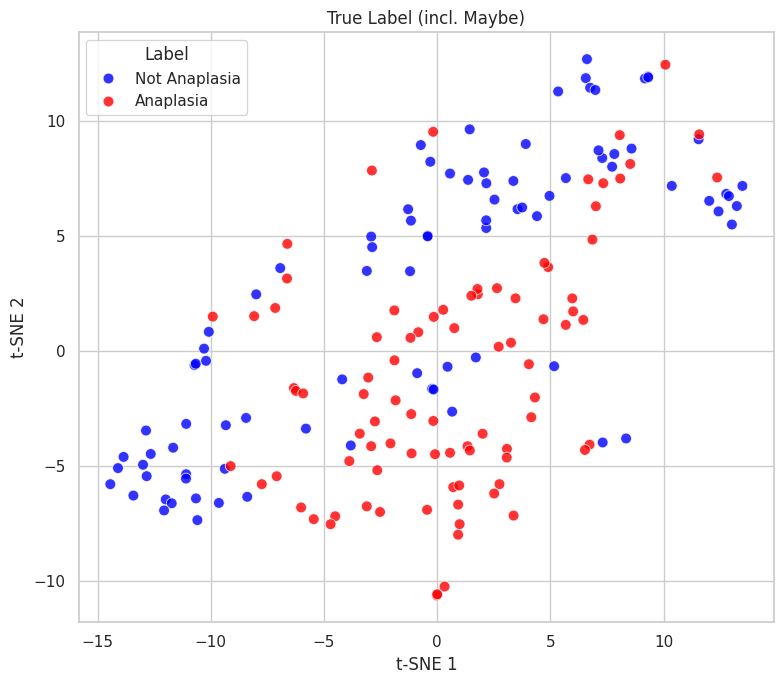

In [100]:

X_2D,dataframe = run_tSNE(feature_dir, label_csv)
""" Type of plot. Multiple (or one) of:
        - "prediction_result" : True/False Positive/Negative
        - "confidence" : Dot size = model confidence, color = correct/wrong
        - "class_correctness" : Color by class, shape by correctness
        - "patient" : Color by patient ID
        - "label" : Color by ground truth class only"""

plot_type = ["label", "prediction_result"]
save_path = f"/opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/{model_name2}/tsne_labels.png"
# plot_features(X_2D, results_df, plot_type=plot_type, save_path=save_path)
plot_features(X_2D,dataframe,plot_type=[("label", False)],save_path=save_path)

In [104]:
import os
import pandas as pd
import numpy as np

base_path = "/opt/app/user/postdoc/Experiments"   # <--- CAMBIA QUI

merged = []

for root, dirs, files in os.walk(base_path):
    if "metrics_summary.csv" in files:
        
        csv_path = os.path.join(root, "metrics_summary.csv")
        
        # Ricava model_type (mlp / lp)
        parts = csv_path.split(os.sep)
        # Esempio: [..., experiment, mlp, all_slides, myexp, metrics_summary.csv]
        model_type = parts[-4]
        slide_subset = parts[-3]
        experiment_name = parts[-2]

        # Carica csv
        df = pd.read_csv(csv_path)

        # Rimuovi colonne indesiderate se presenti
        for col in ["Unnamed: 0", "fold"]:
            if col in df.columns:
                df = df.drop(columns=[col])

        # Inserisci metadati come prime colonne
        df.insert(0, "experiment_name", experiment_name)
        df.insert(1, "model_type", model_type)
        df.insert(2, "slide_subset", slide_subset)

        # Arrotonda tutte le colonne numeriche a 4 decimali
        for col in df.columns:
            if np.issubdtype(df[col].dtype, np.number):
                df[col] = df[col].round(4)

        merged.append(df)

# Merge finale
merged_df = pd.concat(merged, ignore_index=True)

# Salva
out_path = os.path.join(base_path, "merged_metrics_summary.csv")
merged_df.to_csv(out_path, index=False)

print("Merged CSV salvato in:", out_path)

Merged CSV salvato in: /opt/app/user/postdoc/Experiments/merged_metrics_summary.csv


In [105]:
import pandas as pd

# Carica il file merged
df = pd.read_csv("/opt/app/user/postdoc/Experiments/merged_metrics_summary.csv")

# Ordina per sicurezza
df = df.sort_values(["experiment_name", "slide_subset", "model_type"]).reset_index(drop=True)

# Identifica le righe mean vs std
df_mean = df[df["Unnamed: 0"] == "mean"] if "Unnamed: 0" in df.columns else df.iloc[::2].copy()
df_std  = df[df["Unnamed: 0"] == "std"]  if "Unnamed: 0" in df.columns else df.iloc[1::2].copy()

# Allinea gli index
df_std.index = df_mean.index

# Colonne delle metriche
metric_cols = ["accuracy", "precision", "recall", "f1"]

# Nuovo dataframe finale
rows = []

for idx in df_mean.index:
    row = df_mean.loc[idx, ["experiment_name", "model_type", "slide_subset"]].copy()

    for m in metric_cols:
        mean_val = df_mean.loc[idx, m]
        std_val  = df_std.loc[idx, m]

        row[m] = f"{mean_val:.4f} ± {std_val:.4f}"

    rows.append(row)

final_df = pd.DataFrame(rows)

# Salva il risultato
final_path = "/opt/app/user/postdoc/Experiments/merged_metrics_summary_collapsed.csv"
final_df.to_csv(final_path, index=False)

print("Creato:", final_path)
print(final_df.head())

Creato: /opt/app/user/postdoc/Experiments/merged_metrics_summary_collapsed.csv
                 experiment_name              model_type slide_subset  \
0           all_slides_0_penalty          linear_probing   all_slides   
2          all_slides_10_penalty          linear_probing   all_slides   
4   all_slides_256hdim_0_penalty  multi_layer_perceptron   all_slides   
6  all_slides_256hdim_10_penalty  multi_layer_perceptron   all_slides   
8   all_slides_256hdim_5_penalty  multi_layer_perceptron   all_slides   

          accuracy        precision           recall               f1  
0  0.6668 ± 0.1188  0.6881 ± 0.1095  0.6848 ± 0.1137  0.6567 ± 0.1206  
2  0.7013 ± 0.0735  0.7175 ± 0.0697  0.7233 ± 0.0824  0.6955 ± 0.0754  
4  0.6455 ± 0.1338  0.6869 ± 0.1144  0.6748 ± 0.1156  0.6385 ± 0.1304  
6  0.6702 ± 0.1085  0.6995 ± 0.0689  0.6939 ± 0.0735  0.6637 ± 0.1054  
8  0.6797 ± 0.0939  0.7104 ± 0.0724  0.7066 ± 0.0779  0.6739 ± 0.0932  


In [108]:
!pip3 install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.8 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 1.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [easyocr]m3/4 [easyocr]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [115]:
import os
import re
import pandas as pd
import easyocr

# === PATH BASE ===
base_path = "/opt/app/user/postdoc/Anaplasia_Classification/Experiments_december/"  # <-- cambialo
csv_in = os.path.join(base_path, "merged_metrics_summary_collapsed.csv")

# === 1. Carica il CSV collassato (mean ± std per metriche) ===
df = pd.read_csv(csv_in)

# === 2. Inizializza EasyOCR ===
# gpu=False se sei su CPU only
reader = easyocr.Reader(['en'], gpu=True)

# Regex per testo tipo: "AUC = 0.76 ± 0.12" o "AUC = 0.76 +/- 0.12"
pattern = re.compile(
    r"AUC\s*=\s*([0-9]*\.?[0-9]+)\s*[^0-9a-zA-Z]\s*([0-9]*\.?[0-9]+)",
    re.IGNORECASE
)

# Mappa (experiment_name, model_type, slide_subset) -> (auc_mean, auc_std)
auc_map = {}

# Se nella cartella i nomi delle subfolder modello sono "lp" e "mlp"
model_type_map = {
    "lp": "linear_probing",
    "mlp": "multi_layer_perceptron",
}

# === 3. Scorri le cartelle e leggi i PNG ===
for root, dirs, files in os.walk(base_path):
    if "mean_roc_curve.png" not in files:
        continue

    img_path = os.path.join(root, "mean_roc_curve.png")

    parts = root.split(os.sep)
    # .../experiment/{mlp|lp}/{all_slides|yes_slides}/{experiment_name}
    model_folder = parts[-3]    # mlp / lp
    slide_subset = parts[-2]    # all_slides / yes_slides
    experiment_name = parts[-1]

    model_type = model_type_map.get(model_folder, model_folder)

    # OCR: lista di stringhe trovate nell'immagine
    text_lines = reader.readtext(img_path, detail=0)
    text = "\n".join(text_lines)

    match = pattern.search(text)
    if not match:
        print(f"⚠️ AUC non trovato in: {img_path}")
        print("Testo letto:")
        print(text)
        continue

    auc_mean = float(match.group(1))
    auc_std = float(match.group(2))

    key = (experiment_name, model_type, slide_subset)
    auc_map[key] = (auc_mean, auc_std)
    print(f"✅ {key} -> AUC = {auc_mean} ± {auc_std}")

# === 4. Aggiungi AUC al dataframe ===
def lookup_auc(row):
    key = (row["experiment_name"], row["model_type"], row["slide_subset"])
    return auc_map.get(key, (None, None))

df["auc_mean"], df["auc_std"] = zip(*df.apply(lookup_auc, axis=1))

# Colonna formattata tipo "0.7600 ± 0.1200"
df["auc"] = df.apply(
    lambda r: f"{r['auc_mean']:.4f} ± {r['auc_std']:.4f}"
    if pd.notnull(r["auc_mean"])
    else "",
    axis=1,
)
df = df.drop(columns=['auc_mean', 'auc_std'])
# === 5. Salva il nuovo CSV ===
csv_out = os.path.join(base_path, "merged_metrics_summary_with_auc.csv")
df.to_csv(csv_out, index=False)

print("✅ Salvato:", csv_out)

✅ ('all_slides_5_penalty', 'linear_probing', 'all_slides') -> AUC = 0.81 ± 0.13
✅ ('all_slides_10_penalty', 'linear_probing', 'all_slides') -> AUC = 0.81 ± 0.13
✅ ('all_slides_0_penalty', 'linear_probing', 'all_slides') -> AUC = 0.81 ± 0.12
✅ ('yes_slides_5_penalty', 'linear_probing', 'yes_slides') -> AUC = 0.86 ± 0.1
✅ ('yes_slides_10_penalty', 'linear_probing', 'yes_slides') -> AUC = 0.85 ± 0.11
✅ ('yes_slides_0_penalty', 'linear_probing', 'yes_slides') -> AUC = 0.83 ± 0.1
✅ ('all_slides_64hdim_5_penalty', 'multi_layer_perceptron', 'all_slides') -> AUC = 0.79 ± 0.12
✅ ('all_slides_256hdim_10_penalty', 'multi_layer_perceptron', 'all_slides') -> AUC = 0.77 ± 0.13
✅ ('all_slides_64hdim_0_penalty', 'multi_layer_perceptron', 'all_slides') -> AUC = 0.78 ± 0.13
✅ ('all_slides_64hdim_10_penalty', 'multi_layer_perceptron', 'all_slides') -> AUC = 0.78 ± 0.12
✅ ('all_slides_256hdim_5_penalty', 'multi_layer_perceptron', 'all_slides') -> AUC = 0.8 ± 0.12
✅ ('all_slides_256hdim_0_penalty', 'multi_

In [ ]:
# miniwiti = pd.read_csv('/data/temporary/pierpaolo/postdoc/Anaplasia_Classification/Complete_cases/wilmstumor.csv')
# miniwiti = miniwiti.rename(columns={'name': 'slide_id'})
# miniwiti.to_csv('/opt/app/user/wilmstumor.csv',index=False)

In [ ]:


# # === CONFIG ===
# features_dir = "/opt/app/user/total_features/features/"        # folder with .pt files
# csv_path = "/data/temporary/pierpaolo/postdoc/Anaplasia_Classification/Complete_cases/wilmstumor.csv"       # CSV with slide_id + label
# feature_dim = 2560                         # change if different (e.g., 1024)
# perplexity = 30                            # try also 10 or 50
# output_dim = 2                             # 2D for plotting

# # === Load CSV ===
# df = pd.read_csv(csv_path)
# df["filename"] = df["slide_id"].astype(str) + ".pt"
# df["feature_path"] = df["filename"].apply(lambda x: os.path.join(features_dir, x))

# # === Load PRISM features ===
# features = []
# labels = []
# slide_ids = []

# for _, row in tqdm(df.iterrows(), total=len(df)):
#     path = row["feature_path"]
#     if os.path.exists(path):
#         feat = torch.load(path)
#         if isinstance(feat, dict):  # handle dict-based .pt files
#             feat = feat.get("features") or feat.get("slide_embedding") or list(feat.values())[0]
#         features.append(feat.squeeze().cpu().numpy())
#         labels.append(row["Diagnose"])
#         slide_ids.append(row["slide_id"])
#     else:
#         print(f"Missing: {path}")

# features = np.vstack(features)  # shape [N, 2560]
# labels = np.array(labels)

# # === t-SNE ===
# print("Running t-SNE...")
# tsne = TSNE(n_components=output_dim, perplexity=perplexity, random_state=42)
# X_2D = tsne.fit_transform(features)

# # # === Plot ===
# # plt.figure(figsize=(10, 7))
# # sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=labels, palette="coolwarm", s=50, alpha=0.8)
# # plt.title("t-SNE of PRISM Slide Embeddings")
# # plt.xlabel("t-SNE 1")
# # plt.ylabel("t-SNE 2")
# # plt.legend(title="Label", loc="best")
# # plt.tight_layout()
# # plt.savefig('/opt/app/user/tSNE_on_prism_perp.png')
# # plt.show()
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # --- Step 1: Define result type per slide ---
# def get_result_label(true, pred):
#     if true == 1 and pred == 1:
#         return "True Positive"
#     elif true == 1 and pred == 0:
#         return "False Negative"
#     elif true == 0 and pred == 1:
#         return "False Positive"
#     elif true == 0 and pred == 0:
#         return "True Negative"

# y_true = results_df["true_label"].values
# y_pred = results_df["pred_label"].values
# result_labels = [get_result_label(t, p) for t, p in zip(y_true, y_pred)]

# # Optional: convert to numpy array for indexing
# result_labels = np.array(result_labels)

# # --- Step 2: Plot ---
# palette = {
#     "True Positive": "#4CAF50",     # Green
#     "False Negative": "#F44336",    # Red
#     "False Positive": "#FF9800",    # Orange
#     "True Negative": "#9E9E9E"      # Gray
# }

# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x=X_2D[:, 0], y=X_2D[:, 1],
#     hue=result_labels,
#     palette=palette,
#     style=result_labels,  # Optional: shape
#     alpha=0.8,
#     s=60
# )

# plt.title("t-SNE of PRISM Slide Embeddings with Prediction Overlay")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Prediction Result", loc="best")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_on_classification.png')
# plt.show()
# # From your updated results_df
# y_true = results_df["true_label"].values
# y_pred = results_df["pred_label"].values
# y_prob = results_df["confidence"].values  # <-- this is what we need
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # === Define correctness ===
# correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])

# # === Define size as model confidence ===
# # For binary classification, confidence = predicted probability of the predicted class
# confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])

# # === Plot ===
# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x=X_2D[:, 0],
#     y=X_2D[:, 1],
#     hue=correctness,
#     size=confidence,
#     sizes=(20, 200),  # min to max dot size
#     palette={"Correct": "#4CAF50", "Wrong": "#F44336"},
#     alpha=0.7
# )

# plt.title("t-SNE of PRISM Slide Embeddings with Prediction Confidence")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Prediction Correctness", loc="best")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_classification_prediction_linear_probe.png')
# plt.show()
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Define color by true class
# class_color = np.array(["Anaplasia" if y == 1 else "Not Anaplasia" for y in y_true])

# # Define marker style by correctness
# correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])
# markers = {"Correct": "o", "Wrong": "X"}

# # Define confidence size
# confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])

# # Create plot
# plt.figure(figsize=(10, 8))
# for label in ["Anaplasia", "Not Anaplasia"]:
#     for corr in ["Correct", "Wrong"]:
#         mask = (class_color == label) & (correctness == corr)
#         plt.scatter(
#             X_2D[mask, 0],
#             X_2D[mask, 1],
#             label=f"{label} | {corr}",
#             s=confidence[mask] * 200,
#             c="red" if label == "Anaplasia" else "blue",
#             marker=markers[corr],
#             alpha=0.7,
#             edgecolor='k' if corr == "Wrong" else 'none',
#             linewidth=0.5
#         )

# plt.title("t-SNE of PRISM Slide Embeddings\nTrue Label + Prediction Correctness + Confidence")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Class | Prediction")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_prediction_probability_linear_probe.png')
# plt.show()
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 8))

# sns.scatterplot(
#     x=X_2D[:, 0],
#     y=X_2D[:, 1],
#     hue=results_df["patient_id"],
#     palette="tab20",  # or "husl", "Spectral", etc. for color variety
#     legend=False,
#     alpha=0.8,
#     s=60
# )

# plt.title("t-SNE of PRISM Slide Embeddings Colored by Patient")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_colored_by_patient.png')
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # --- Step 1: Define result type per slide ---
# def get_result_label(true, pred):
#     if true == 1 and pred == 1:
#         return "True Positive"
#     elif true == 1 and pred == 0:
#         return "False Negative"
#     elif true == 0 and pred == 1:
#         return "False Positive"
#     elif true == 0 and pred == 0:
#         return "True Negative"

# y_true = results_df["true_label"].values
# y_pred = results_df["pred_label"].values
# result_labels = [get_result_label(t, p) for t, p in zip(y_true, y_pred)]

# # Optional: convert to numpy array for indexing
# result_labels = np.array(result_labels)

# # --- Step 2: Plot ---
# palette = {
#     "True Positive": "#4CAF50",     # Green
#     "False Negative": "#F44336",    # Red
#     "False Positive": "#FF9800",    # Orange
#     "True Negative": "#9E9E9E"      # Gray
# }

# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x=X_2D[:, 0], y=X_2D[:, 1],
#     hue=result_labels,
#     palette=palette,
#     style=result_labels,  # Optional: shape
#     alpha=0.8,
#     s=60
# )

# plt.title("t-SNE of PRISM Slide Embeddings with Prediction Overlay")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Prediction Result", loc="best")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_on_classification.png')
# plt.show()

In [ ]:
# # From your updated results_df
# y_true = results_df["true_label"].values
# y_pred = results_df["pred_label"].values
# y_prob = results_df["confidence"].values  # <-- this is what we need

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # === Define correctness ===
# correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])

# # === Define size as model confidence ===
# # For binary classification, confidence = predicted probability of the predicted class
# confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])

# # === Plot ===
# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x=X_2D[:, 0],
#     y=X_2D[:, 1],
#     hue=correctness,
#     size=confidence,
#     sizes=(20, 200),  # min to max dot size
#     palette={"Correct": "#4CAF50", "Wrong": "#F44336"},
#     alpha=0.7
# )

# plt.title("t-SNE of PRISM Slide Embeddings with Prediction Confidence")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Prediction Correctness", loc="best")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_classification_prediction_linear_probe.png')
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Define color by true class
# class_color = np.array(["Anaplasia" if y == 1 else "Not Anaplasia" for y in y_true])

# # Define marker style by correctness
# correctness = np.array(["Correct" if t == p else "Wrong" for t, p in zip(y_true, y_pred)])
# markers = {"Correct": "o", "Wrong": "X"}

# # Define confidence size
# confidence = np.array([prob if pred == 1 else 1 - prob for prob, pred in zip(y_prob, y_pred)])

# # Create plot
# plt.figure(figsize=(10, 8))
# for label in ["Anaplasia", "Not Anaplasia"]:
#     for corr in ["Correct", "Wrong"]:
#         mask = (class_color == label) & (correctness == corr)
#         plt.scatter(
#             X_2D[mask, 0],
#             X_2D[mask, 1],
#             label=f"{label} | {corr}",
#             s=confidence[mask] * 200,
#             c="red" if label == "Anaplasia" else "blue",
#             marker=markers[corr],
#             alpha=0.7,
#             edgecolor='k' if corr == "Wrong" else 'none',
#             linewidth=0.5
#         )

# plt.title("t-SNE of PRISM Slide Embeddings\nTrue Label + Prediction Correctness + Confidence")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Class | Prediction")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_prediction_probability_linear_probe.png')
# plt.show()

In [ ]:
# X_tsne=X_2D 

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 8))

# sns.scatterplot(
#     x=X_2D[:, 0],
#     y=X_2D[:, 1],
#     hue=results_df["patient_id"],
#     palette="tab20",  # or "husl", "Spectral", etc. for color variety
#     legend=False,
#     alpha=0.8,
#     s=60
# )

# plt.title("t-SNE of PRISM Slide Embeddings Colored by Patient")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.tight_layout()
# plt.savefig('/opt/app/user/tsne_colored_by_patient.png')
# plt.show()